<a href="https://colab.research.google.com/github/irakafc/Portfolio/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#
Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np# importar librerías

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:

plans.head()# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:

users.head()# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
#
usage.head()# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
print("\n===== INFO: PLANS =====")
plans.info()
# inspección de plans con .info()


===== INFO: PLANS =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
print("\n===== INFO: USERS =====")
users.info()
# inspección de users con .info()


===== INFO: USERS =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
print("\n===== INFO: USAGE =====")
usage.info()
# inspección de usage con .info()


===== INFO: USAGE =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users



print(users.isnull().sum())# Cantidad de valores nulos)
print((users.isnull().sum() / len(users)) * 100)




user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [ ]:
print(usage.isnull().sum())# Cantidad de valores nulos)
print((usage.isnull().sum() / len(usage)) * 100)
# cantidad de nulos para usage

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡

## **Valores nulos — `users`**

- `city` → 469 valores nulos (**11.73%**)  
  → **Decisión:** Investigar para imputar o dejar como nulo.  
  → **Justificación:** El porcentaje es moderado y la ciudad puede ser importante para análisis geográficos y segmentación.

- `churn_date` → 3534 valores nulos (**88.35%**)  
  → **Decisión:** Ignorar los nulos.  
  → **Justificación:** Los nulos probablemente representan clientes que no han cancelado el servicio, por lo que tienen significado analítico.

---

## **Valores nulos — `usage`**

- `date` → 50 valores nulos (**0.125%**)  
  → **Decisión:** Eliminar o imputar.  
  → **Justificación:** El porcentaje es muy bajo y no afectará significativamente el análisis.

- `duration` → 22076 valores nulos (**55.19%**)  
  → **Decisión:** Mantener los nulos.  
  → **Justificación:** La duración probablemente solo aplica a registros de llamadas y no a mensajes.

- `length` → 17896 valores nulos (**44.74%**)  
  → **Decisión:** Mantener los nulos.  
  → **Justificación:** La longitud probablemente solo aplica a mensajes y no a llamadas.



### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
print("===== USERS - NUMÉRICAS =====")
print(users.describe())# explorar columnas numéricas de users

===== USERS - NUMÉRICAS =====
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000



## **Exploración de columnas numéricas**

- La columna `user_id` parece consistente, ya que los identificadores son únicos y se encuentran dentro de un rango lógico.

- La columna `age` presenta un posible sentinel o valor inválido, ya que el valor mínimo es `-999`, lo cual no es una edad válida y probablemente representa un dato faltante o error de captura.

In [ ]:
print("\n===== USAGE - NUMÉRICAS =====")
print(usage.describe())
# explorar columnas numéricas de usage


===== USAGE - NUMÉRICAS =====
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


## **Exploración de columnas numéricas — `usage`**

- Las columnas `id` y `user_id` parecen consistentes, ya que no presentan valores negativos ni rangos anormales.

- La columna `duration` no presenta valores inválidos evidentes; sin embargo, existen llamadas con duración `0`, las cuales podrían representar llamadas canceladas o no completadas.

- La columna `length` presenta mensajes con longitud `0`, lo cual podría indicar mensajes vacíos o registros incompletos.

- Los valores máximos de `duration` (`120`) y `length` (`1490`) son considerablemente altos y podrían representar casos atípicos que conviene revisar durante el análisis exploratorio.


In [ ]:
# ==========================================
# Explorar columnas categóricas de users
# ==========================================

columnas_user = ['city', 'plan']

for columna in columnas_user:
    print(f'\n===== {columna.upper()} =====')
    print(users[columna].value_counts(dropna=False))
    print('\nValores únicos:')
    print(users[columna].unique())


===== CITY =====
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores únicos:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

===== PLAN =====
Basico     2595
Premium    1405
Name: plan, dtype: int64

Valores únicos:
['Basico' 'Premium']



- La columna `city` contiene múltiples ciudades y presenta valores nulos, aunque no se observan categorías inválidas evidentes a simple vista.

- La columna `plan` contiene únicamente las categorías esperadas y no presenta inconsistencias en los nombres de los planes.

In [ ]:
# explorar columna categórica de usage

print("===== TYPE =====")
print(usage['type'].value_counts(dropna=False))

print("\nValores únicos:")
print(usage['type'].unique())

===== TYPE =====
text    22092
call    17908
Name: type, dtype: int64

Valores únicos:
['call' 'text']


- La columna `type` contiene categorías consistentes y válidas para los tipos de uso del servicio, sin valores extraños o inconsistentes visibles.

---

## **Valores inválidos o sentinels**

- En la columna `age` del dataset `users` se detectó el valor `-999`, el cual es un sentinel porque no representa una edad válida.  
  → **Acción recomendada:** reemplazar esos valores por `NaN` para posteriormente imputarlos o analizarlos por separado.

- En las columnas `duration` y `length` del dataset `usage` existen valores iguales a `0`.  
  → **Acción recomendada:** investigar si representan llamadas no completadas o mensajes vacíos antes de decidir eliminarlos.

- En la columna `duration` se observaron valores máximos relativamente altos (`120` minutos), y en `length` valores de hasta `1490` caracteres.  
  → **Acción recomendada:** revisar estos registros como posibles valores atípicos durante el análisis exploratorio.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código


In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])# completa el código

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()

array([2022.,   nan, 2023., 2024.])

En `reg_date` se observan registros con el año 2026, cuando los datos deberían contener únicamente fechas hasta 2024. Esto indica posibles errores de captura, carga o formato en la columna de fechas.

Se recomienda revisar esos registros específicos y validar si las fechas deben corregirse, eliminarse o marcarse como datos inválidos antes de continuar con el análisis.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2024.,   nan])



En la columna date se observan valores NaN, lo que indica que existen registros con fechas faltantes. Dado que el análisis se basará en esta columna, estos valores podrían afectar cálculos, agrupaciones o métricas temporales.

Se recomienda revisar la cantidad de valores faltantes y decidir si conviene eliminarlos, imputarlos o excluir esos registros del análisis dependiendo del contexto del proyecto.




✍️ Comentario:

Fechas fuera de rango

Sí, aparecen años fuera del rango esperado, como registros en 2026 cuando el conjunto de datos debería llegar solo hasta 2024. Esto sugiere errores de captura, carga o transformación de datos.
Recomendaría identificar esos registros y validarlos. Si no es posible corregir la fecha original, lo más adecuado sería eliminarlos o excluirlos del análisis para evitar distorsiones en métricas temporales y conclusiones del proyecto.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:

# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)


# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].unique()


array(['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [ ]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].mask(users['reg_date'].dt.year > 2024, pd.NA)


# Verificar los años presentes después de la limpieza
users['reg_date'].dt.year.unique()


array([2022.,   nan, 2023., 2024.])

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:



# Verificación MAR en usage (Missing At Random) para duration

print("=== Verificación MAR para duration ===")
print("Valores nulos por tipo:")

print(usage.groupby('type')['duration'].apply(lambda x: x.isnull().sum()))

print("\nTotal de registros por tipo:")
print(usage['type'].value_counts())




=== Verificación MAR para duration ===
Valores nulos por tipo:
type
call        0
text    22076
Name: duration, dtype: int64

Total de registros por tipo:
text    22092
call    17908
Name: type, dtype: int64


In [ ]:


# Verificación MAR en usage (Missing At Random) para length
print("=== Verificación MAR para length ===")
print("Valores nulos por tipo:")

print(usage.groupby('type')['length'].apply(lambda x: x.isnull().sum()))

print("\nTotal de registros por tipo:")
print(usage['type'].value_counts())



=== Verificación MAR para length ===
Valores nulos por tipo:
type
call    17896
text        0
Name: length, dtype: int64

Total de registros por tipo:
text    22092
call    17908
Name: type, dtype: int64


Los valores nulos en duration y length sí dependen de la columna type, por lo que se consideran MAR (Missing At Random).

En los registros de tipo text, prácticamente todos los valores de duration son nulos, lo cual tiene sentido porque los mensajes de texto no tienen duración de llamada.
En los registros de tipo call, casi todos los valores de length son nulos, ya que las llamadas no manejan longitud de mensaje.

Esto indica que los nulos no son errores de captura, sino que están relacionados con la naturaleza del tipo de uso registrado.

Por esta razón, se recomienda conservar los valores nulos tal como están y no imputarlos, ya que representan correctamente casos donde la variable no aplica.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text", "is_call", "duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")

user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
# Resumen estadístico de columnas numéricas
user_profile.describe()




,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.122250,5.524381,4.478120,23.317054
std,1154.844867,17.690408,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,47.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

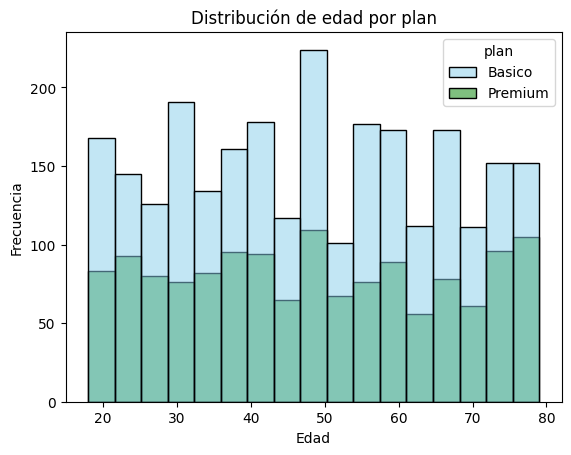

In [ ]:

# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()



✍️ Insight:
Se observa que el plan Básico tiene aproximadamente el doble de usuarios que el plan Premium en casi todos los rangos de edad. Sin embargo, la forma de la distribución es similar entre ambos planes, por lo que no parece existir una relación clara entre la edad y el tipo de plan contratado. La distribución es relativamente uniforme y cercana a simétrica.

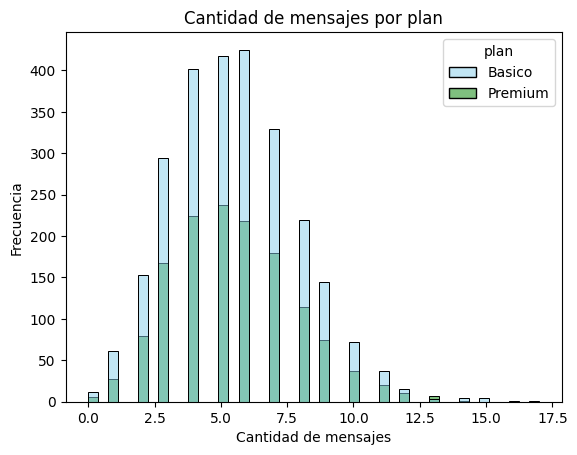

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'])
plt.title('Cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()


✍️ Insight:
Los usuarios del plan Básico son aproximadamente el doble que los del plan Premium en la mayoría de los niveles de uso. Ambos planes muestran una distribución sesgada a la derecha, ya que existen pocos usuarios con cantidades muy altas de mensajes. No se observa una diferencia drástica en el patrón de uso entre planes.

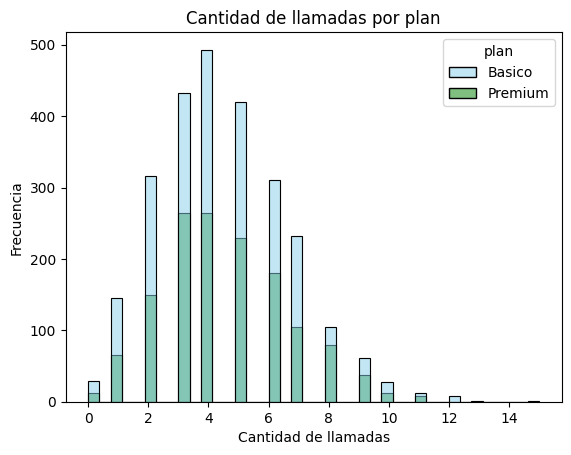

In [ ]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'])
plt.title('Cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()


✍️ Insight:
El plan Básico presenta aproximadamente el doble de usuarios que Premium en casi todos los niveles de llamadas. La distribución está sesgada a la derecha, indicando que algunos usuarios realizan muchas más llamadas que la mayoría. El comportamiento entre planes es bastante similar.

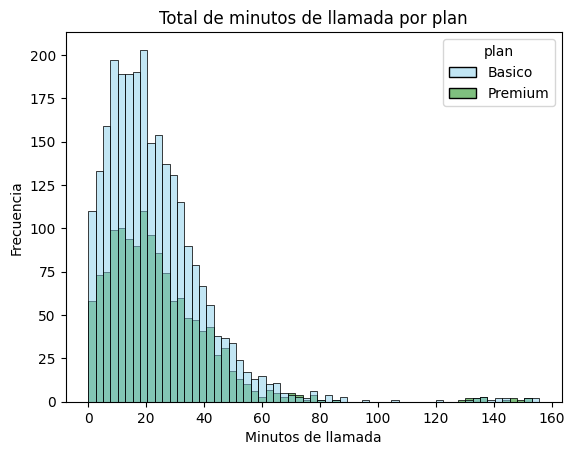

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'])
plt.title('Total de minutos de llamada por plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
Se observa una mayor cantidad de usuarios en el plan Básico respecto al Premium, aproximadamente el doble en la mayoría de los rangos. La distribución está sesgada a la derecha debido a usuarios con consumos altos de minutos de llamada. El plan Basico representa el doblee de uso de minutos en la mayoria de los casos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

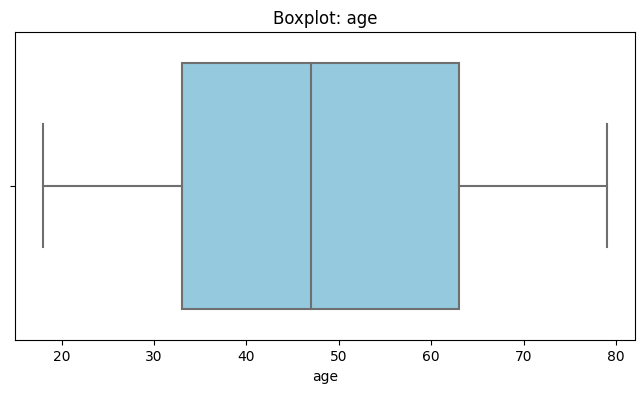

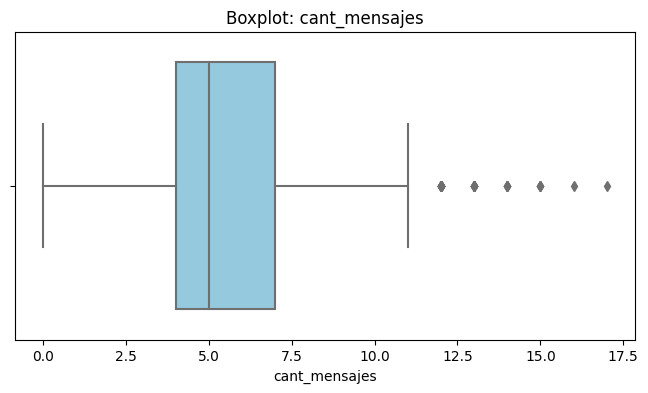

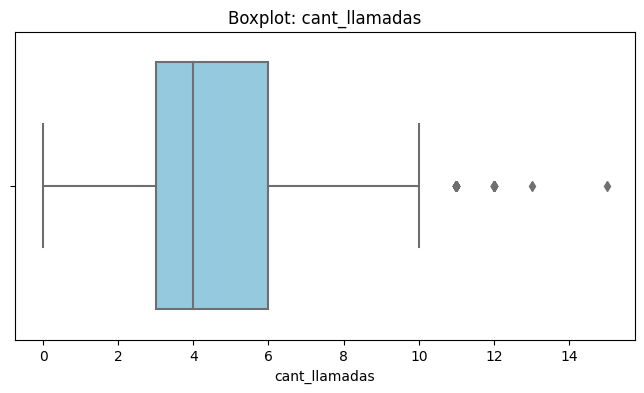

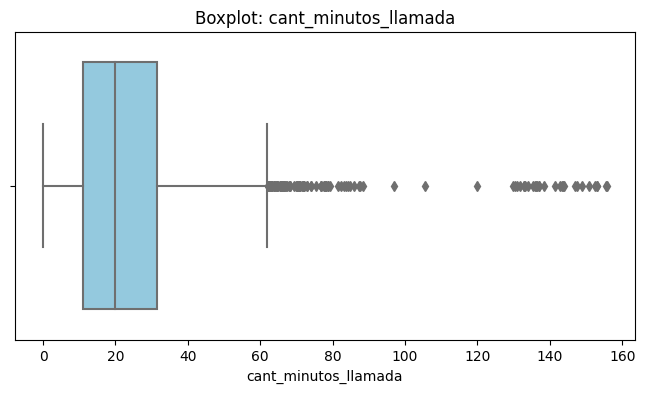

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:

    plt.figure(figsize=(8, 4))

    sns.boxplot(x=user_profile[col], color='skyblue')

    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)

    plt.show()

💡 **Insights:**

- **Age:** No presenta outliers visibles. La distribución de edades se mantiene dentro de un rango esperado y relativamente uniforme.

- **cant_mensajes:** Sí presenta algunos outliers en el extremo superior. Existen usuarios que envían una cantidad considerablemente mayor de mensajes que la mayoría, aunque son pocos casos.

- **cant_llamadas:** Sí presenta outliers superiores. Algunos usuarios realizan muchas más llamadas que el comportamiento típico observado en el conjunto de datos.

- **cant_minutos_llamada:** Es la variable con mayor cantidad de outliers. Se observan varios usuarios con consumos extremadamente altos de minutos de llamada, especialmente en el extremo derecho de la distribución. Estos casos probablemente representan usuarios intensivos y no necesariamente errores.



In [ ]:
# Calcular límites con el método IQR

columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:

    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f'\nVariable: {col}')
    print(f'Q1: {Q1}')
    print(f'Q3: {Q3}')
    print(f'IQR: {IQR}')
    print(f'Límite inferior: {limite_inferior}')
    print(f'Límite superior: {limite_superior}')


Variable: cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite inferior: -0.5
Límite superior: 11.5

Variable: cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite inferior: -1.5
Límite superior: 10.5

Variable: cant_minutos_llamada
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite inferior: -19.322500000000005
Límite superior: 61.8575


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000



💡 **Insights:**

- **cant_mensajes:** Se recomienda mantener los outliers, ya que representan usuarios con una actividad de mensajería más alta de lo normal y no parecen ser errores de captura. Además, los valores máximos siguen siendo razonables dentro del contexto del negocio.

- **cant_llamadas:** Se recomienda conservar los outliers porque probablemente corresponden a usuarios con un uso intensivo del servicio de llamadas. No se observan valores imposibles o inconsistentes.

- **cant_minutos_llamada:** Aunque esta variable presenta la mayor cantidad de outliers, se recomienda mantenerlos, ya que reflejan comportamientos reales de clientes con alto consumo de minutos. Eliminarlos podría sesgar el análisis y reducir información relevante sobre usuarios intensivos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso


def clasificar_uso(row):

    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'

    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'

    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

# Verificar resultado
user_profile[['cant_llamadas', 'cant_mensajes', 'grupo_uso']].head()

,cant_llamadas,cant_mensajes,grupo_uso
0,3.0,7.0,Uso medio
1,10.0,5.0,Alto uso
2,2.0,5.0,Uso medio
3,3.0,11.0,Alto uso
4,3.0,4.0,Bajo uso


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad


def clasificar_edad(row):

    if row['age'] < 30:
        return 'Joven'

    elif row['age'] < 60:
        return 'Adulto'

    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

# Verificar resultado
user_profile[['age', 'grupo_edad']].head()

,age,grupo_edad
0,38.0,Adulto
1,53.0,Adulto
2,57.0,Adulto
3,69.0,Adulto Mayor
4,63.0,Adulto Mayor


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

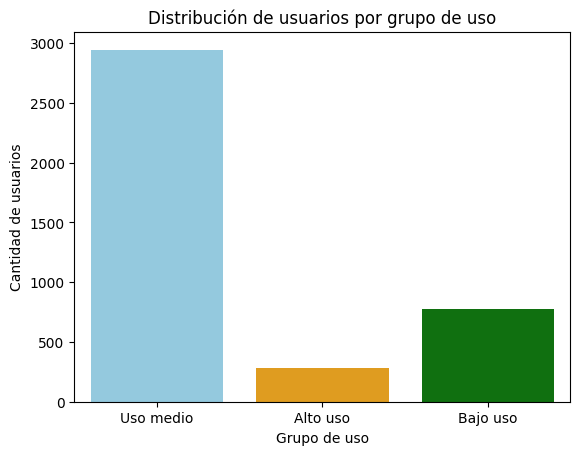

In [ ]:

# Visualización de los segmentos por uso


sns.countplot(data=user_profile, x='grupo_uso', palette=['skyblue', 'orange', 'green'])

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()


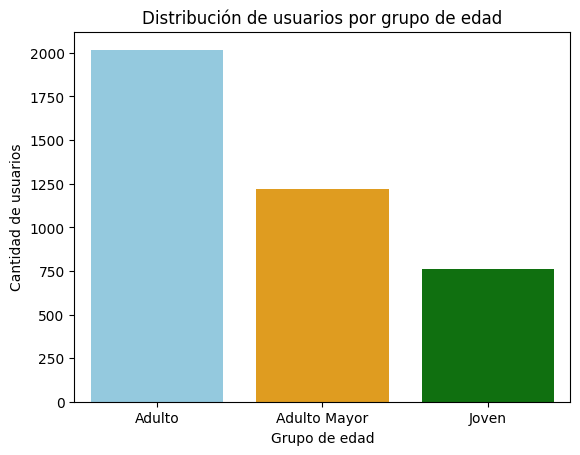

In [ ]:


# Visualización de los segmentos por edad


sns.countplot(data=user_profile, x='grupo_edad', palette=['skyblue', 'orange', 'green'])

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


⚠️ **Problemas detectados en los datos**
- Se identificaron valores sentinel en distintas columnas. En `age` existían registros con el valor `-999`, los cuales representaban edades inválidas y fueron reemplazados por la mediana para evitar distorsionar el análisis.
- En la columna `city` se encontraron registros con `"?"`, los cuales fueron tratados como valores nulos (`NA`) debido a la falta de información válida.
- En `reg_date` aparecieron fechas futuras, incluyendo años como 2026, cuando el análisis debía limitarse hasta 2024. Estos registros fueron convertidos a valores nulos.
- También se encontraron valores nulos en variables como `duration` y `length`, pero se confirmó que eran datos MAR (Missing At Random), ya que dependían directamente del tipo de uso (`call` o `text`). Por ello, se mantuvieron sin imputar.


🔍 **Segmentos por Edad**
- Se identificaron tres grupos principales: Jóvenes, Adultos y Adultos Mayores.
- La mayoría de usuarios se concentra en el grupo Adulto, mientras que los segmentos de Jóvenes y Adultos Mayores representan una menor proporción.
- No se observaron diferencias extremadamente marcadas entre los planes Básico y Premium según edad.


📊 **Segmentos por Nivel de Uso**
- Los usuarios fueron segmentados en Bajo uso, Uso medio y Alto uso según la cantidad de llamadas y mensajes.
- La mayoría de clientes se concentra en el segmento de Uso medio, mientras que existe un grupo menor de usuarios intensivos con niveles altos de llamadas y minutos consumidos.
- El plan Básico concentra aproximadamente el doble de usuarios que el plan Premium en la mayoría de los análisis realizados.
- Se identificaron outliers principalmente en `cant_mensajes`, `cant_llamadas` y especialmente en `cant_minutos_llamada`, reflejando usuarios con consumos muy superiores al promedio.


➡️ Esto sugiere que ConnectaTel tiene una base de clientes dominada por usuarios de consumo moderado y plan Básico, pero también cuenta con un grupo reducido de clientes intensivos que podrían representar una oportunidad importante de monetización mediante planes especializados o beneficios premium.


💡 **Recomendaciones**
- Diseñar planes específicos para usuarios de alto consumo, incluyendo paquetes con mayores beneficios en minutos y mensajes para incentivar migraciones al plan Premium.
- Mantener planes accesibles para usuarios de bajo y medio consumo, ya que representan la mayoría de la base de clientes.
- Implementar mejores controles de calidad de datos para evitar fechas imposibles, sentinels y registros inconsistentes en futuras capturas.
- Analizar más profundamente a los usuarios con consumo extremo, ya que podrían corresponder a clientes de alto valor o a comportamientos específicos que requieran productos personalizados.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`